# Segmento de Reta

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (ponto, reta, notação geométrica, postulado de determinação da reta e pontos colineares). Ajuda ter visto intervalos em [`0103a_conjuntos_numericos.ipynb`](../01_conjuntos_e_funcoes/0103a_conjuntos_numericos.ipynb) e módulo em [`0110a_funcao_modular.ipynb`](../01_conjuntos_e_funcoes/0110a_funcao_modular.ipynb), mas não é obrigatório.

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir segmento de reta e semirreta a partir da reta, e diferenciar os três objetos (reta, semirreta e segmento) pela definição e pela notação.
- Medir e comparar segmentos, reconhecendo quando dois segmentos são congruentes.
- Encontrar o ponto médio de um segmento, tanto algébrica quanto graficamente.
- Classificar pares de segmentos como consecutivos, colineares e/ou adjacentes, e somar e subtrair medidas de segmentos colineares.

**Tempo estimado:** 45 a 60 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0402a_segmento_de_reta.ipynb)

## O que uma régua mede, afinal?

No notebook anterior você viu que a reta é **infinita**: não tem começo nem fim. Agora pegue uma régua e meça a caneta que está na sua mesa. Deu, digamos, 14,5 cm.

Mas espera: se a reta é infinita, **o que exatamente a régua mediu?** Ela não mediu "a reta". Ela mediu um **pedaço** da reta, que começa em um ponto (a ponta da caneta encostada no 0) e termina em outro (a outra ponta, no 14,5). Um pedaço **limitado**, com começo e fim.

Outra situação: no mapa do celular, você quer saber a distância da sua casa até a escola. O aplicativo mostra dois números: a distância **pelas ruas** e a distância **em linha reta**. A segunda é sempre menor ou igual à primeira. Por quê? Porque o caminho em linha reta entre dois pontos é o mais curto possível, e esse caminho também é um "pedaço de reta" com começo e fim.

Esse pedaço limitado de reta tem nome: **segmento de reta**. Ele é o objeto que a gente mede, compara, divide ao meio e soma. É dele que trata este notebook.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def pontas_na_janela(p1, p2, lo: float, hi: float) -> tuple:
    """Devolve os dois pontos onde a reta que passa por p1 e p2 sai da janela quadrada [lo, hi]."""
    p = np.array(p1, dtype=float)
    u = np.array(p2, dtype=float) - p
    t_entrada, t_saida = -np.inf, np.inf
    for k in range(2):
        if abs(u[k]) > 1e-12:
            t0, t1 = (lo - p[k]) / u[k], (hi - p[k]) / u[k]
            t_entrada = max(t_entrada, min(t0, t1))
            t_saida = min(t_saida, max(t0, t1))
    return p + t_entrada * u, p + t_saida * u


def desenhar_reta(ax, p1, p2, cor: str = COR_SECUNDARIA, lo: float = -6, hi: float = 6, largura: float = 2) -> None:
    """Desenha a reta por p1 e p2 de borda a borda da janela, com setas nas duas pontas (a reta não acaba)."""
    inicio, fim = pontas_na_janela(p1, p2, lo + 0.3, hi - 0.3)
    ax.annotate("", xy=fim, xytext=inicio,
                arrowprops=dict(arrowstyle="<|-|>", color=cor, lw=largura, mutation_scale=16))


def desenhar_semirreta(ax, origem, outro, cor: str = COR_DESTAQUE, lo: float = -6, hi: float = 6, largura: float = 2) -> None:
    """Desenha a semirreta de origem `origem` que passa por `outro`: seta só no sentido de `outro`."""
    ponta_1, ponta_2 = pontas_na_janela(origem, outro, lo + 0.3, hi - 0.3)
    sentido = np.array(outro, dtype=float) - np.array(origem, dtype=float)
    fim = ponta_1 if np.dot(ponta_1 - np.array(origem, dtype=float), sentido) > 0 else ponta_2
    ax.annotate("", xy=fim, xytext=origem,
                arrowprops=dict(arrowstyle="-|>", color=cor, lw=largura, mutation_scale=16))


def desenhar_segmento(ax, p1, p2, cor: str = COR_PONTO, largura: float = 3) -> None:
    """Desenha o segmento de extremidades p1 e p2 (sem setas: ele começa e termina)."""
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=cor, lw=largura, solid_capstyle="butt", zorder=3)


def desenhar_ponto(ax, p, nome: str, cor: str = COR_AVISO, deslocamento=(0.15, 0.25)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=8, zorder=5)
    ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def marcar_congruencia(ax, p1, p2, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.25) -> None:
    """Desenha tracinhos no meio do segmento p1p2: a marca usada nos desenhos para indicar segmentos congruentes."""
    p1, p2 = np.array(p1, dtype=float), np.array(p2, dtype=float)
    direcao = (p2 - p1) / np.linalg.norm(p2 - p1)
    normal = np.array([-direcao[1], direcao[0]])
    meio = (p1 + p2) / 2
    for k in range(tracos):
        centro = meio + (k - (tracos - 1) / 2) * 0.2 * direcao
        a, b = centro + tamanho * normal, centro - tamanho * normal
        ax.plot([a[0], b[0]], [a[1], b[1]], color=cor, lw=2, zorder=6)

Vamos ver as duas situações do gancho lado a lado. À esquerda, a reta continua para sempre (as setas lembram isso), mas a régua só consegue medir o pedaço entre A e B. À direita, o caminho pelas ruas da casa até a escola é comparado com o caminho em linha reta.

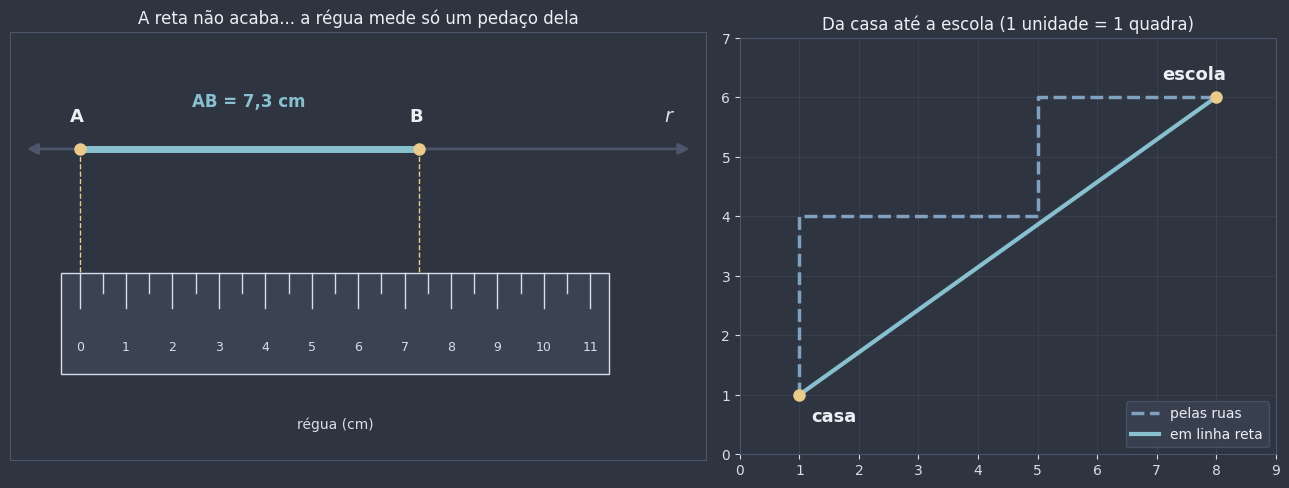

Pelas ruas:     12.00 quadras
Em linha reta:  8.60 quadras  (o menor caminho possível)


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: a reta é infinita, mas a régua mede só o pedaço entre A e B
estilizar_eixo(ax1)
ax1.grid(False)
ax1.set_xlim(-1.5, 13.5)
ax1.set_ylim(-3, 2.5)
ax1.set_xticks([])
ax1.set_yticks([])
desenhar_reta(ax1, (0, 1), (12, 1), cor=NORD_LINHA, lo=-1.5, hi=13.5)
ax1.text(12.6, 1.35, "r", color=NORD_TEXTO_SEC, fontsize=14, fontstyle="italic")

ponto_a, ponto_b = (0, 1), (7.3, 1)
desenhar_segmento(ax1, ponto_a, ponto_b, cor=COR_PONTO, largura=5)
desenhar_ponto(ax1, ponto_a, "A", deslocamento=(-0.2, 0.35))
desenhar_ponto(ax1, ponto_b, "B", deslocamento=(-0.2, 0.35))

# A régua, com marcações a cada meio centímetro
ax1.add_patch(plt.Rectangle((-0.4, -1.9), 11.8, 1.3, facecolor=NORD_PAINEL, edgecolor=NORD_TEXTO_SEC, lw=1))
for marca in np.arange(0, 11.01, 0.5):
    altura = 0.45 if marca == int(marca) else 0.25
    ax1.plot([marca, marca], [-0.6, -0.6 - altura], color=NORD_TEXTO_SEC, lw=1)
    if marca == int(marca):
        ax1.text(marca, -1.6, f"{int(marca)}", color=NORD_TEXTO_SEC, fontsize=9, ha="center")
for x in (ponto_a[0], ponto_b[0]):
    ax1.plot([x, x], [1, -0.6], color=COR_AVISO, lw=1, linestyle="--")
ax1.text(3.65, 1.55, "AB = 7,3 cm", color=COR_PONTO, fontsize=12, ha="center", fontweight="bold")
ax1.text(5.5, -2.6, "régua (cm)", color=NORD_TEXTO_SEC, fontsize=10, ha="center")
ax1.set_title("A reta não acaba... a régua mede só um pedaço dela", color=NORD_TEXTO, fontsize=12)

# Direita: pelas ruas x em linha reta
estilizar_eixo(ax2)
ax2.set_xlim(0, 9)
ax2.set_ylim(0, 7)
ax2.set_aspect("equal")
ax2.set_xticks(range(10))
ax2.set_yticks(range(8))
casa, escola = (1, 1), (8, 6)
caminho_ruas = np.array([casa, (1, 4), (5, 4), (5, 6), escola])
ax2.plot(caminho_ruas[:, 0], caminho_ruas[:, 1], color=COR_SECUNDARIA, lw=2.5, linestyle="--", label="pelas ruas")
desenhar_segmento(ax2, casa, escola, cor=COR_PONTO, largura=3)
ax2.plot([], [], color=COR_PONTO, lw=3, label="em linha reta")
desenhar_ponto(ax2, casa, "casa", deslocamento=(0.2, -0.45))
desenhar_ponto(ax2, escola, "escola", deslocamento=(-0.9, 0.3))
ax2.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO, loc="lower right")
ax2.set_title("Da casa até a escola (1 unidade = 1 quadra)", color=NORD_TEXTO, fontsize=12)

plt.tight_layout()
plt.show()

comprimento_ruas = sum(math.dist(p, q) for p, q in zip(caminho_ruas[:-1], caminho_ruas[1:]))
comprimento_reto = math.dist(casa, escola)
print(f"Pelas ruas:     {comprimento_ruas:.2f} quadras")
print(f"Em linha reta:  {comprimento_reto:.2f} quadras  (o menor caminho possível)")

## 1. Da reta ao segmento: semirreta e segmento de reta

A reta é ilimitada nos dois sentidos. Para obter objetos **limitados**, a gente "corta" a reta com pontos.

**Cortando com um ponto: a semirreta.** Um ponto O sobre uma reta r divide a reta em duas partes. Cada uma dessas partes, **junto com o próprio O**, é uma **semirreta de origem O**: começa em O e segue ilimitada em **um só sentido**. As duas semirretas formadas são chamadas **semirretas opostas**.

📌 **Definição formal (semirreta):** dados dois pontos distintos O e A, a **semirreta** $\overrightarrow{OA}$ é formada pelo ponto O e por todos os pontos da reta $\overleftrightarrow{OA}$ que estão do **mesmo lado de O que o ponto A**. O ponto O é a **origem** da semirreta.

**Cortando com dois pontos: o segmento.** Dois pontos distintos A e B sobre a reta delimitam um pedaço limitado **dos dois lados**.

📌 **Definição formal (segmento de reta):** o **segmento de reta** $\overline{AB}$ (também escrito $[AB]$) é a reunião dos pontos A e B com **todos os pontos que estão entre A e B**. Os pontos A e B são as **extremidades** do segmento. Se A = B, o segmento se reduz a um único ponto e é chamado de **segmento nulo**.

| Objeto | É limitado? | Notação | Como se desenha |
|---|---|---|---|
| **Reta** | não: ilimitada nos **dois** sentidos | r ou $\overleftrightarrow{AB}$ | seta nas duas pontas |
| **Semirreta** | só de **um** lado (a origem) | $\overrightarrow{AB}$ (origem A, passando por B) | seta numa ponta só |
| **Segmento** | dos **dois** lados (as extremidades) | $\overline{AB}$ ou $[AB]$ | sem setas, extremidades marcadas |

Repare num detalhe da notação: $\overline{AB}$ e $\overline{BA}$ são **o mesmo segmento** (os mesmos pontos), mas $\overrightarrow{AB}$ e $\overrightarrow{BA}$ são semirretas **diferentes**: uma começa em A e vai na direção de B; a outra começa em B e vai na direção de A.

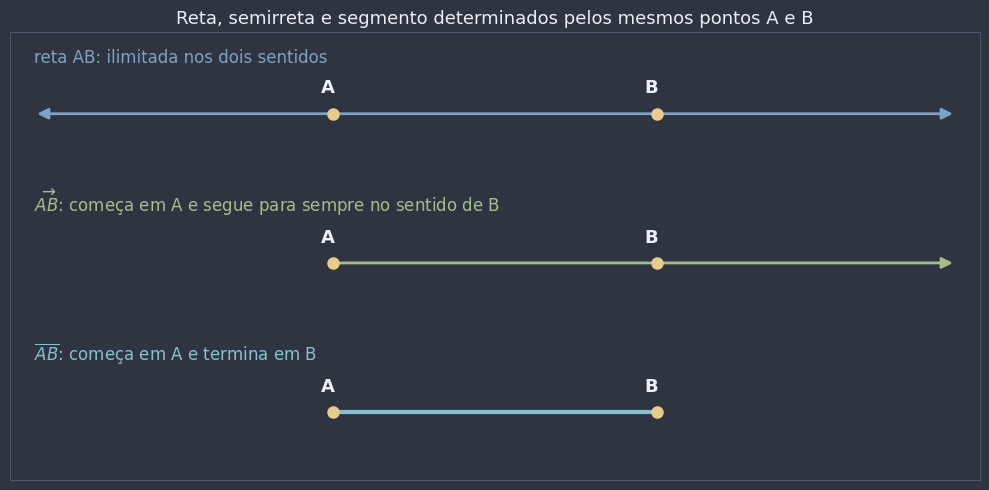

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.grid(False)
ax.set_xlim(-6, 6)
ax.set_ylim(-3.2, 3.4)
ax.set_xticks([])
ax.set_yticks([])

x_a, x_b = -2, 2
linhas_do_desenho = [
    (2.2, "reta", "reta AB: ilimitada nos dois sentidos", COR_SECUNDARIA),
    (0.0, "semirreta", r"$\overrightarrow{AB}$: começa em A e segue para sempre no sentido de B", COR_DESTAQUE),
    (-2.2, "segmento", r"$\overline{AB}$: começa em A e termina em B", COR_PONTO),
]
for y, tipo, legenda, cor in linhas_do_desenho:
    if tipo == "reta":
        desenhar_reta(ax, (x_a, y), (x_b, y), cor=cor)
    elif tipo == "semirreta":
        desenhar_semirreta(ax, (x_a, y), (x_b, y), cor=cor)
    else:
        desenhar_segmento(ax, (x_a, y), (x_b, y), cor=cor, largura=3)
    desenhar_ponto(ax, (x_a, y), "A", deslocamento=(-0.15, 0.3))
    desenhar_ponto(ax, (x_b, y), "B", deslocamento=(-0.15, 0.3))
    ax.text(-5.7, y + 0.75, legenda, color=cor, fontsize=12)

ax.set_title("Reta, semirreta e segmento determinados pelos mesmos pontos A e B", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

Agora as **semirretas opostas**: o ponto O divide a reta r em duas semirretas, $\overrightarrow{OA}$ e $\overrightarrow{OB}$, que só têm o ponto O em comum e, juntas, formam a reta inteira.

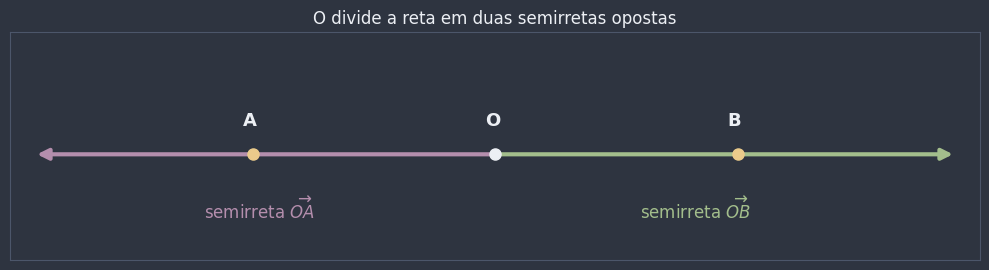

In [4]:
fig, ax = plt.subplots(figsize=(10, 2.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.grid(False)
ax.set_xlim(-6, 6)
ax.set_ylim(-1.3, 1.5)
ax.set_xticks([])
ax.set_yticks([])

ponto_o, ponto_a, ponto_b = (0, 0), (-3, 0), (3, 0)
desenhar_semirreta(ax, ponto_o, ponto_a, cor=COR_EXTRA, largura=3)
desenhar_semirreta(ax, ponto_o, ponto_b, cor=COR_DESTAQUE, largura=3)
desenhar_ponto(ax, ponto_o, "O", cor=NORD_TEXTO, deslocamento=(-0.12, 0.35))
desenhar_ponto(ax, ponto_a, "A", deslocamento=(-0.12, 0.35))
desenhar_ponto(ax, ponto_b, "B", deslocamento=(-0.12, 0.35))
ax.text(-3.6, -0.8, r"semirreta $\overrightarrow{OA}$", color=COR_EXTRA, fontsize=12)
ax.text(1.8, -0.8, r"semirreta $\overrightarrow{OB}$", color=COR_DESTAQUE, fontsize=12)
ax.set_title("O divide a reta em duas semirretas opostas", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

**Na reta numerada.** Se cada ponto da reta for identificado com um número real (a posição dele na reta numerada), esses objetos viram conjuntos de números que você já conhece. Com A na posição $a$ e B na posição $b$, sendo $a < b$:

| Objeto | Conjunto de posições | Em notação de intervalo |
|---|---|---|
| reta $\overleftrightarrow{AB}$ | todos os números reais | $\mathbb{R}$ |
| semirreta $\overrightarrow{AB}$ | $x \geq a$ | $[a, +\infty[$ |
| semirreta $\overrightarrow{BA}$ | $x \leq b$ | $]-\infty, b]$ |
| segmento $\overline{AB}$ | $a \leq x \leq b$ | $[a, b]$ |

📎 **Conexão:** é daqui que vem a notação $[AB]$ com colchetes: o segmento é exatamente um **intervalo fechado** da reta numerada, como em [`0103a_conjuntos_numericos.ipynb`](../01_conjuntos_e_funcoes/0103a_conjuntos_numericos.ipynb). E note que o segmento $\overline{AB}$ é a **interseção** das semirretas $\overrightarrow{AB}$ e $\overrightarrow{BA}$: os pontos que estão, ao mesmo tempo, "de A para o lado de B" e "de B para o lado de A".

Vamos testar alguns pontos com A em −2 e B em 3:

In [5]:
posicao_a, posicao_b = -2.0, 3.0


def marca(condicao: bool) -> str:
    """Troca True/False por um símbolo mais fácil de ler na tabela."""
    return "✅" if condicao else "❌"


def onde_esta(x: float, a: float, b: float) -> dict:
    """Diz a quais objetos (reta, semirretas, segmento) pertence o ponto de posição x, com a < b."""
    return {
        "posição x": x,
        "reta AB": marca(True),
        "semirreta AB (x ≥ a)": marca(x >= a),
        "semirreta BA (x ≤ b)": marca(x <= b),
        "segmento AB (a ≤ x ≤ b)": marca(a <= x <= b),
    }


posicoes_testadas = [-5.0, -2.0, 0.0, 1.5, 3.0, 4.2, 10.0]
tabela_pertinencia = pd.DataFrame([onde_esta(x, posicao_a, posicao_b) for x in posicoes_testadas])
display(tabela_pertinencia.style.format({"posição x": "{:g}"}).hide(axis="index"))

posição x,reta AB,semirreta AB (x ≥ a),semirreta BA (x ≤ b),segmento AB (a ≤ x ≤ b)
-5,✅,❌,✅,❌
-2,✅,✅,✅,✅
0,✅,✅,✅,✅
1.5,✅,✅,✅,✅
3,✅,✅,✅,✅
4.2,✅,✅,❌,❌
10,✅,✅,❌,❌


🕹️ **Widget interativo:** mova o ponto P pela reta com o slider. Em cada uma das quatro faixas, P fica **verde** se pertence ao objeto desenhado e **vermelho** se não pertence. Tente descobrir: existe alguma posição de P que está no segmento $\overline{AB}$ mas **não** está nas duas semirretas? E alguma posição que está nas duas semirretas mas fora do segmento?

In [6]:
def mostrar_onde_esta_p(posicao_p: float) -> None:
    fig, ax = plt.subplots(figsize=(10, 4.4))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.grid(False)
    ax.set_xlim(-6.3, 6.3)
    ax.set_ylim(-0.9, 4.2)
    ax.set_yticks([])

    faixas = [
        (3.3, "reta", "reta AB", True),
        (2.2, "semi_ab", r"semirreta $\overrightarrow{AB}$", posicao_p >= posicao_a),
        (1.1, "semi_ba", r"semirreta $\overrightarrow{BA}$", posicao_p <= posicao_b),
        (0.0, "segmento", r"segmento $\overline{AB}$", posicao_a <= posicao_p <= posicao_b),
    ]
    for y, tipo, rotulo, pertence in faixas:
        a, b = (posicao_a, y), (posicao_b, y)
        if tipo == "reta":
            desenhar_reta(ax, a, b, cor=COR_SECUNDARIA, lo=-6.3, hi=6.3)
        elif tipo == "semi_ab":
            desenhar_semirreta(ax, a, b, cor=COR_SECUNDARIA, lo=-6.3, hi=6.3)
        elif tipo == "semi_ba":
            desenhar_semirreta(ax, b, a, cor=COR_SECUNDARIA, lo=-6.3, hi=6.3)
        else:
            desenhar_segmento(ax, a, b, cor=COR_SECUNDARIA, largura=3)
        ax.plot(*a, "o", color=COR_AVISO, markersize=6, zorder=4)
        ax.plot(*b, "o", color=COR_AVISO, markersize=6, zorder=4)
        cor_p = COR_DESTAQUE if pertence else COR_ALERTA
        ax.plot(posicao_p, y, "o", color=cor_p, markersize=12, zorder=6)
        ax.text(-6.1, y + 0.3, f"{rotulo}: P {'pertence' if pertence else 'não pertence'}", color=cor_p, fontsize=10)

    ax.set_xticks([posicao_a, posicao_b, posicao_p])
    ax.set_xticklabels([f"A\n{posicao_a:g}", f"B\n{posicao_b:g}", f"P\n{posicao_p:.1f}"], color=NORD_TEXTO_SEC)
    ax.set_title(f"P na posição {posicao_p:.1f}", color=NORD_TEXTO, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    mostrar_onde_esta_p,
    posicao_p=widgets.FloatSlider(value=1.0, min=-6, max=6, step=0.1, description="posição de P:"),
);

interactive(children=(FloatSlider(value=1.0, description='posição de P:', max=6.0, min=-6.0), Output()), _dom_…

⚠️ **Erro comum:** usar a mesma escrita para objetos diferentes, como dizer "a reta AB" quando se quer falar do **segmento** AB, ou escrever $\overline{AB}$ para uma reta. Na geometria a notação carrega informação: letra **minúscula** (r, s) ou $\overleftrightarrow{AB}$ é **reta**; $\overrightarrow{AB}$ é **semirreta** (e a primeira letra é sempre a origem); $\overline{AB}$ ou $[AB]$ é **segmento**. E, como você vai ver na próxima seção, **AB sem nenhum símbolo** é um **número**: a medida do segmento.

📖 **Leitura complementar:** [Segmento de reta](https://pt.wikipedia.org/wiki/Segmento_de_reta) · [Semirreta](https://pt.wikipedia.org/wiki/Semirreta)

**Pergunta de checagem:** um ponto qualquer sobre uma reta sempre divide essa reta em duas semirretas. Isso também vale para um ponto M no meio de um segmento $\overline{AB}$? Em que M divide o segmento?

**Pergunta de checagem:** $\overrightarrow{AB}$ e $\overrightarrow{BA}$ são a mesma semirreta? E $\overline{AB}$ e $\overline{BA}$, são o mesmo segmento? Explique usando a tabela da reta numerada.

## 2. Medida, comparação e congruência de segmentos

Medir um segmento é compará-lo com um segmento escolhido como **unidade** (1 cm, 1 m, 1 km...) e contar quantas vezes a unidade cabe nele. O resultado é a **medida** (ou comprimento) do segmento.

📌 **Medida de um segmento:** a medida de $\overline{AB}$ é indicada por **AB** (sem traço em cima) ou por $m(\overline{AB})$. Ela é sempre um número **positivo**; a única exceção é o segmento nulo, cuja medida é **zero**.

**Como calcular a medida?**
- **Na reta numerada**, com A na posição $a$ e B na posição $b$: $\quad AB = |b - a|$. O módulo garante que o resultado não fica negativo, não importa qual ponto está à esquerda (📎 [`0110a_funcao_modular.ipynb`](../01_conjuntos_e_funcoes/0110a_funcao_modular.ipynb)).
- **No plano**, com $A = (x_A, y_A)$ e $B = (x_B, y_B)$:

$$AB = \sqrt{(x_B - x_A)^2 + (y_B - y_A)^2}$$

Essa é a **fórmula da distância entre dois pontos**. Ela vem do Teorema de Pitágoras aplicado ao triângulo retângulo cujos catetos são o "quanto andou na horizontal" ($\Delta x$) e o "quanto andou na vertical" ($\Delta y$). Por enquanto, aceite a fórmula e veja que ela funciona; Pitágoras aparece mais adiante neste módulo, e a fórmula é estudada com calma em Geometria Analítica.

**Comparando dois segmentos**, só há três possibilidades: $AB > CD$, $AB < CD$ ou $AB = CD$. Esse último caso ganha um nome especial:

📌 **Segmentos congruentes:** $\overline{AB}$ e $\overline{CD}$ são **congruentes** quando têm a **mesma medida**. Notação: $\overline{AB} \equiv \overline{CD}$ (lê-se "AB é congruente a CD").

$$\overline{AB} \equiv \overline{CD} \iff AB = CD$$

Nos desenhos, segmentos congruentes costumam receber a mesma quantidade de **tracinhos** no meio, para mostrar que têm o mesmo tamanho sem precisar escrever os números.

Na reta numerada:
  A =    2, B =    9  ->  AB = |9 - (2)| = 7
  A =    9, B =    2  ->  AB = |2 - (9)| = 7
  A =   -3, B =    4  ->  AB = |4 - (-3)| = 7
  A = -7.5, B =   -1  ->  AB = |-1 - (-7.5)| = 6.5

No plano: A = (1, 1), B = (5, 4)  ->  AB = 5
Conferindo com math.dist, que o Python já traz pronto: 5


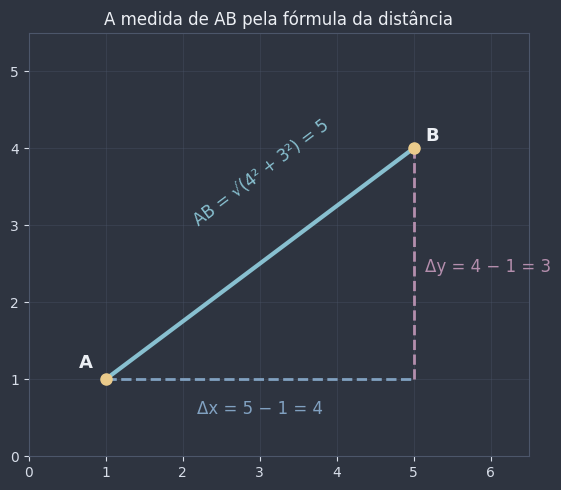

In [7]:
def medida_segmento(p1: tuple[float, float], p2: tuple[float, float]) -> float:
    """Devolve a medida do segmento de extremidades p1 e p2 (fórmula da distância)."""
    (x1, y1), (x2, y2) = p1, p2
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


# Na reta numerada: módulo da diferença
print("Na reta numerada:")
for a, b in [(2, 9), (9, 2), (-3, 4), (-7.5, -1)]:
    print(f"  A = {a:>4}, B = {b:>4}  ->  AB = |{b} - ({a})| = {abs(b - a):g}")

# No plano: fórmula da distância
ponto_a, ponto_b = (1, 1), (5, 4)
print(f"\nNo plano: A = {ponto_a}, B = {ponto_b}  ->  AB = {medida_segmento(ponto_a, ponto_b):g}")
print(f"Conferindo com math.dist, que o Python já traz pronto: {math.dist(ponto_a, ponto_b):g}")

# Visualização: Δx e Δy são os catetos do triângulo retângulo
fig, ax = plt.subplots(figsize=(6.5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.set_xlim(0, 6.5)
ax.set_ylim(0, 5.5)
ax.set_aspect("equal")
canto = (ponto_b[0], ponto_a[1])
ax.plot([ponto_a[0], canto[0]], [ponto_a[1], canto[1]], color=COR_SECUNDARIA, lw=2, linestyle="--")
ax.plot([canto[0], ponto_b[0]], [canto[1], ponto_b[1]], color=COR_EXTRA, lw=2, linestyle="--")
desenhar_segmento(ax, ponto_a, ponto_b, cor=COR_PONTO)
desenhar_ponto(ax, ponto_a, "A", deslocamento=(-0.35, 0.15))
desenhar_ponto(ax, ponto_b, "B", deslocamento=(0.15, 0.1))
ax.text(3, 0.55, "Δx = 5 − 1 = 4", color=COR_SECUNDARIA, fontsize=12, ha="center")
ax.text(5.15, 2.4, "Δy = 4 − 1 = 3", color=COR_EXTRA, fontsize=12)
ax.text(2.1, 3.0, "AB = √(4² + 3²) = 5", color=COR_PONTO, fontsize=12, rotation=37)
ax.set_title("A medida de AB pela fórmula da distância", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

Com a função `medida_segmento`, podemos comparar vários segmentos de uma vez e descobrir quais são congruentes, mesmo que estejam em lugares e direções bem diferentes do plano:

segmento,extremidade 1,extremidade 2,medida
AB,"(-5, 1)","(-2, 5)",5
CD,"(0, 4)","(5, 4)",5
EF,"(2, -5)","(5, -1)",5
GH,"(-5, -4)","(-1, -4)",4
IJ,"(0, -2)","(0, 1)",3


Congruentes (medida 5): AB ≡ CD ≡ EF


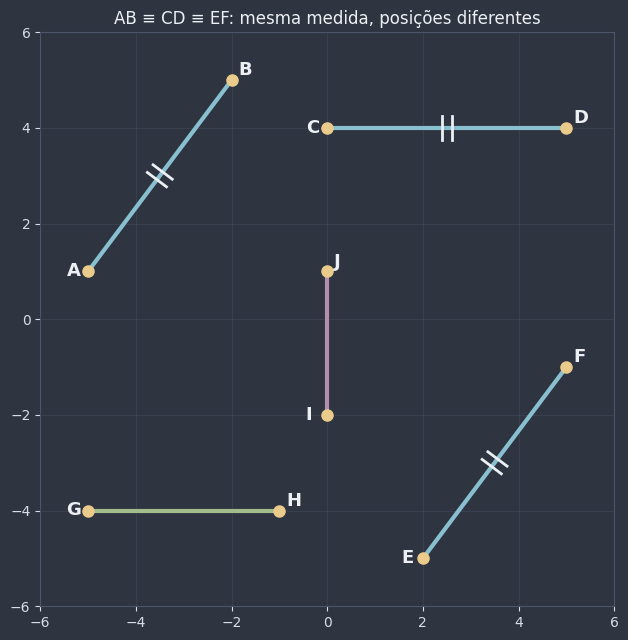

In [8]:
segmentos = {
    "AB": ((-5, 1), (-2, 5)),
    "CD": ((0, 4), (5, 4)),
    "EF": ((2, -5), (5, -1)),
    "GH": ((-5, -4), (-1, -4)),
    "IJ": ((0, -2), (0, 1)),
}

tabela_medidas = pd.DataFrame(
    [{"segmento": nome, "extremidade 1": p1, "extremidade 2": p2, "medida": medida_segmento(p1, p2)}
     for nome, (p1, p2) in segmentos.items()]
)
display(tabela_medidas.style.format({"medida": "{:g}"}).hide(axis="index"))

# Agrupa os segmentos pela medida: quem cai no mesmo grupo é congruente
grupos: dict[float, list[str]] = {}
for nome, (p1, p2) in segmentos.items():
    grupos.setdefault(round(medida_segmento(p1, p2), 9), []).append(nome)
for medida, nomes in grupos.items():
    if len(nomes) > 1:
        print(f"Congruentes (medida {medida:g}): " + " ≡ ".join(nomes))

# Desenho: segmentos congruentes com a mesma cor e os mesmos tracinhos
cores_por_medida = {5.0: COR_PONTO, 4.0: COR_DESTAQUE, 3.0: COR_EXTRA}
fig, ax = plt.subplots(figsize=(6.5, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
for nome, (p1, p2) in segmentos.items():
    medida = round(medida_segmento(p1, p2), 9)
    desenhar_segmento(ax, p1, p2, cor=cores_por_medida[medida])
    if len(grupos[medida]) > 1:
        marcar_congruencia(ax, p1, p2, tracos=2)
    desenhar_ponto(ax, p1, nome[0], deslocamento=(-0.45, -0.1))
    desenhar_ponto(ax, p2, nome[1], deslocamento=(0.15, 0.1))
ax.set_title("AB ≡ CD ≡ EF: mesma medida, posições diferentes", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

📌 **Propriedades da congruência de segmentos.** Como ela é definida pela igualdade das medidas, herda as propriedades da igualdade de números:
- **Reflexiva:** $\overline{AB} \equiv \overline{AB}$ (todo segmento é congruente a si mesmo).
- **Simétrica:** se $\overline{AB} \equiv \overline{CD}$, então $\overline{CD} \equiv \overline{AB}$.
- **Transitiva:** se $\overline{AB} \equiv \overline{CD}$ e $\overline{CD} \equiv \overline{EF}$, então $\overline{AB} \equiv \overline{EF}$.

📎 **Conexão:** essas são as mesmas propriedades de relações que você viu em [`0104a_relacoes.ipynb`](../01_conjuntos_e_funcoes/0104a_relacoes.ipynb). Uma relação reflexiva, simétrica e transitiva é chamada de **relação de equivalência**, e a congruência de segmentos é um exemplo geométrico dela.

💡 **Dica — por que "congruente" e não "igual"?** Em números, dizemos que $5 = 5$. Em figuras, "igual" daria a ideia de que são **a mesma figura**, no mesmo lugar. Mas $\overline{AB}$, $\overline{CD}$ e $\overline{EF}$ do desenho acima são segmentos **diferentes** (em lugares diferentes do plano) que têm o mesmo **tamanho**. "Congruente" é a palavra da geometria para "mesmo tamanho e mesma forma, não importa onde esteja".

🎯 **Aplicação prática — régua, trena e a unidade de referência:** todo instrumento de medida carrega uma **unidade**: a régua em centímetros, a trena às vezes em polegadas, e antigamente se media em palmos e pés. A medida de um segmento **muda** com a unidade, mas a comparação entre dois segmentos **não muda**: se dois segmentos são congruentes em centímetros, são congruentes em qualquer unidade. Veja com três segmentos medidos em unidades diferentes:

In [9]:
centimetros_por_unidade = {"cm": 1.0, "polegadas": 2.54, "palmos (≈ 20 cm)": 20.0}
medidas_em_cm = {"tampo da mesa": 120.0, "porta": 80.0, "estante": 120.0}

tabela_unidades = pd.DataFrame(
    {unidade: {objeto: cm / fator for objeto, cm in medidas_em_cm.items()}
     for unidade, fator in centimetros_por_unidade.items()}
)
display(tabela_unidades.style.format("{:.2f}"))

for unidade, fator in centimetros_por_unidade.items():
    razao = (medidas_em_cm["tampo da mesa"] / fator) / (medidas_em_cm["porta"] / fator)
    print(f"Em {unidade:<17}: tampo / porta = {razao:.2f}   |   tampo ≡ estante? "
          f"{math.isclose(medidas_em_cm['tampo da mesa'] / fator, medidas_em_cm['estante'] / fator)}")

,cm,polegadas,palmos (≈ 20 cm)
tampo da mesa,120.00,47.24,6.00
porta,80.00,31.50,4.00
estante,120.00,47.24,6.00


Em cm               : tampo / porta = 1.50   |   tampo ≡ estante? True
Em polegadas        : tampo / porta = 1.50   |   tampo ≡ estante? True
Em palmos (≈ 20 cm) : tampo / porta = 1.50   |   tampo ≡ estante? True


🕹️ **Widget interativo:** use os sliders para mudar as medidas de $\overline{AB}$ e $\overline{CD}$. Os dois segmentos começam em lugares diferentes, de propósito: o que importa é o tamanho. O título mostra a comparação e, quando as medidas coincidem, os segmentos ficam verdes e ganham os tracinhos de congruência.

In [ ]:
def comparar_segmentos(medida_ab: float, medida_cd: float) -> None:
    fig, ax = plt.subplots(figsize=(9, 3.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.set_xlim(-0.5, 11)
    ax.set_ylim(-2.2, 2.4)
    ax.set_yticks([])

    a, b = (0.5, 1), (0.5 + medida_ab, 1)
    c, d = (2.0, -1), (2.0 + medida_cd, -1)
    congruentes = math.isclose(medida_ab, medida_cd)
    cor_ab = COR_DESTAQUE if congruentes else COR_PONTO
    cor_cd = COR_DESTAQUE if congruentes else COR_EXTRA
    desenhar_segmento(ax, a, b, cor=cor_ab, largura=4)
    desenhar_segmento(ax, c, d, cor=cor_cd, largura=4)
    if congruentes:
        marcar_congruencia(ax, a, b, tracos=1)
        marcar_congruencia(ax, c, d, tracos=1)
    for p, nome in [(a, "A"), (b, "B"), (c, "C"), (d, "D")]:
        desenhar_ponto(ax, p, nome, deslocamento=(-0.12, 0.35))
    ax.text(a[0], 1.8, f"AB = {medida_ab:g}", color=cor_ab, fontsize=11)
    ax.text(c[0], -1.9, f"CD = {medida_cd:g}", color=cor_cd, fontsize=11)

    if congruentes:
        titulo, cor_titulo = "AB = CD: congruentes ✓", COR_DESTAQUE
    elif medida_ab > medida_cd:
        titulo, cor_titulo = f"AB > CD (diferença de {medida_ab - medida_cd:g})", COR_AVISO
    else:
        titulo, cor_titulo = f"AB < CD (diferença de {medida_cd - medida_ab:g})", COR_AVISO
    ax.set_title(titulo, color=cor_titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    comparar_segmentos,
    medida_ab=widgets.FloatSlider(value=3, min=0.5, max=8, step=0.5, description="medida AB:"),
    medida_cd=widgets.FloatSlider(value=5, min=0.5, max=8, step=0.5, description="medida CD:"),
);

interactive(children=(FloatSlider(value=3.0, description='medida AB:', max=8.0, min=0.5, step=0.5), FloatSlide…

**Pergunta de checagem:** dois segmentos congruentes precisam estar na mesma reta? E precisam ter uma extremidade em comum? Use o desenho com $\overline{AB}$, $\overline{CD}$ e $\overline{EF}$ para responder.

**Pergunta de checagem:** na reta numerada, A está em −4 e B em 3. Por que a conta $3 - (-4)$ e a conta $|-4 - 3|$ dão o mesmo resultado, mas $-4 - 3$ não serve como medida?

## 3. Ponto médio de um segmento

📌 **Definição formal (ponto médio):** o **ponto médio** de $\overline{AB}$ é o ponto M **pertencente ao segmento** tal que $\overline{AM} \equiv \overline{MB}$. Ele divide o segmento em duas partes congruentes, e é **único**: cada segmento tem um, e só um, ponto médio.

Como as duas metades têm a mesma medida:

$$AM = MB = \frac{AB}{2}$$

**Calculando a posição de M:**
- **Na reta numerada**, com A em $a$ e B em $b$, o ponto médio fica na **média** das duas posições: $\quad m = \dfrac{a + b}{2}$.
- **No plano**, faz-se a média separadamente para cada coordenada:

$$M = \left(\frac{x_A + x_B}{2},\ \frac{y_A + y_B}{2}\right)$$

Por que funciona? Para ir de A até M, você anda **metade** do $\Delta x$ e **metade** do $\Delta y$ que andaria para ir de A até B. Chegando exatamente na metade do caminho nas duas direções, você está na metade do segmento.

A = (-3, -1), B = (5, 3)
M = ((-3 + 5)/2, (-1 + 3)/2) = (1.0, 1.0)
AM = 4.4721
MB = 4.4721
AB/2 = 4.4721


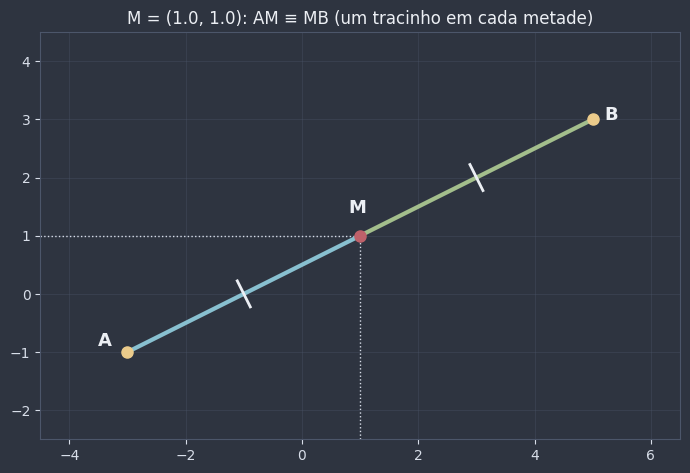

In [11]:
def ponto_medio(p1: tuple[float, float], p2: tuple[float, float]) -> tuple[float, float]:
    """Devolve o ponto médio do segmento de extremidades p1 e p2."""
    return ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)


ponto_a, ponto_b = (-3, -1), (5, 3)
ponto_m = ponto_medio(ponto_a, ponto_b)
print(f"A = {ponto_a}, B = {ponto_b}")
print(f"M = (({ponto_a[0]} + {ponto_b[0]})/2, ({ponto_a[1]} + {ponto_b[1]})/2) = {ponto_m}")
print(f"AM = {medida_segmento(ponto_a, ponto_m):.4f}")
print(f"MB = {medida_segmento(ponto_m, ponto_b):.4f}")
print(f"AB/2 = {medida_segmento(ponto_a, ponto_b) / 2:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.set_xlim(-4.5, 6.5)
ax.set_ylim(-2.5, 4.5)
ax.set_aspect("equal")
desenhar_segmento(ax, ponto_a, ponto_m, cor=COR_PONTO)
desenhar_segmento(ax, ponto_m, ponto_b, cor=COR_DESTAQUE)
marcar_congruencia(ax, ponto_a, ponto_m, tracos=1)
marcar_congruencia(ax, ponto_m, ponto_b, tracos=1)
desenhar_ponto(ax, ponto_a, "A", deslocamento=(-0.5, 0.1))
desenhar_ponto(ax, ponto_b, "B", deslocamento=(0.2, 0.0))
desenhar_ponto(ax, ponto_m, "M", cor=COR_ALERTA, deslocamento=(-0.2, 0.4))
# Linhas-guia: M está na metade do caminho em x e em y
ax.plot([ponto_m[0], ponto_m[0]], [-2.5, ponto_m[1]], color=NORD_TEXTO_SEC, lw=1, linestyle=":")
ax.plot([-4.5, ponto_m[0]], [ponto_m[1], ponto_m[1]], color=NORD_TEXTO_SEC, lw=1, linestyle=":")
ax.set_title(f"M = {ponto_m}: AM ≡ MB (um tracinho em cada metade)", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

A mesma conta, feita para vários segmentos, mostra na tabela que sempre $AM = MB = AB/2$:

In [12]:
pares_de_extremidades = [((0, 0), (8, 0)), ((-3, -1), (5, 3)), ((2, 7), (2, -1)), ((-4, 5), (1, -2)), ((1.5, 2.5), (6.5, 0.5))]

linhas = []
for a, b in pares_de_extremidades:
    m = ponto_medio(a, b)
    linhas.append({
        "A": a, "B": b, "M": m,
        "AM": medida_segmento(a, m), "MB": medida_segmento(m, b), "AB/2": medida_segmento(a, b) / 2,
    })
tabela_pontos_medios = pd.DataFrame(linhas)
display(tabela_pontos_medios.style.format({"AM": "{:.4f}", "MB": "{:.4f}", "AB/2": "{:.4f}"}).hide(axis="index"))

A,B,M,AM,MB,AB/2
"(0, 0)","(8, 0)","(4.0, 0.0)",4.0000,4.0000,4.0000
"(-3, -1)","(5, 3)","(1.0, 1.0)",4.4721,4.4721,4.4721
"(2, 7)","(2, -1)","(2.0, 3.0)",4.0000,4.0000,4.0000
"(-4, 5)","(1, -2)","(-1.5, 1.5)",4.3012,4.3012,4.3012
"(1.5, 2.5)","(6.5, 0.5)","(4.0, 1.5)",2.6926,2.6926,2.6926


🕹️ **Widget interativo:** mova as extremidades A e B com os sliders. O ponto médio M é recalculado na hora, e as duas metades continuam sempre congruentes. Experimente deixar A e B na mesma altura, na mesma vertical, ou colocar B exatamente em cima de A (segmento nulo).

In [ ]:
def mostrar_ponto_medio(x_a: float, y_a: float, x_b: float, y_b: float) -> None:
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(-6.5, 6.5)
    ax.set_aspect("equal")

    a, b = (x_a, y_a), (x_b, y_b)
    m = ponto_medio(a, b)
    if a == b:
        desenhar_ponto(ax, a, "A = B = M", cor=COR_ALERTA)
        ax.set_title("Segmento nulo: medida 0, e M coincide com A e B", color=COR_AVISO, fontsize=11)
    else:
        desenhar_segmento(ax, a, m, cor=COR_PONTO)
        desenhar_segmento(ax, m, b, cor=COR_DESTAQUE)
        marcar_congruencia(ax, a, m)
        marcar_congruencia(ax, m, b)
        desenhar_ponto(ax, a, "A")
        desenhar_ponto(ax, b, "B")
        desenhar_ponto(ax, m, "M", cor=COR_ALERTA)
        metade = medida_segmento(a, m)
        ax.set_title(f"M = ({m[0]:g}, {m[1]:g})   |   AM = MB = {metade:.2f}   |   AB = {2 * metade:.2f}",
                     color=NORD_TEXTO, fontsize=11)
    plt.tight_layout()
    plt.show()


widgets.interact(
    mostrar_ponto_medio,
    x_a=widgets.FloatSlider(value=-4, min=-6, max=6, step=0.5, description="x de A:"),
    y_a=widgets.FloatSlider(value=-2, min=-6, max=6, step=0.5, description="y de A:"),
    x_b=widgets.FloatSlider(value=4, min=-6, max=6, step=0.5, description="x de B:"),
    y_b=widgets.FloatSlider(value=3, min=-6, max=6, step=0.5, description="y de B:"),
);

interactive(children=(FloatSlider(value=-4.0, description='x de A:', max=6.0, min=-6.0, step=0.5), FloatSlider…

🎯 **Aplicação prática — centralizar na tela é calcular ponto médio:** quando um site ou um jogo mostra um botão "bem no meio" da tela, o programa fez uma conta de ponto médio. O centro da tela é o ponto médio entre a borda esquerda (x = 0) e a direita (x = largura), e entre a borda de cima e a de baixo. Para centralizar o botão, basta colocar o **centro do botão** nesse ponto.

Centro da tela: (640, 360)
O botão começa em x = 460 e termina em x = 820
Sobra à esquerda: 460 px | sobra à direita: 460 px


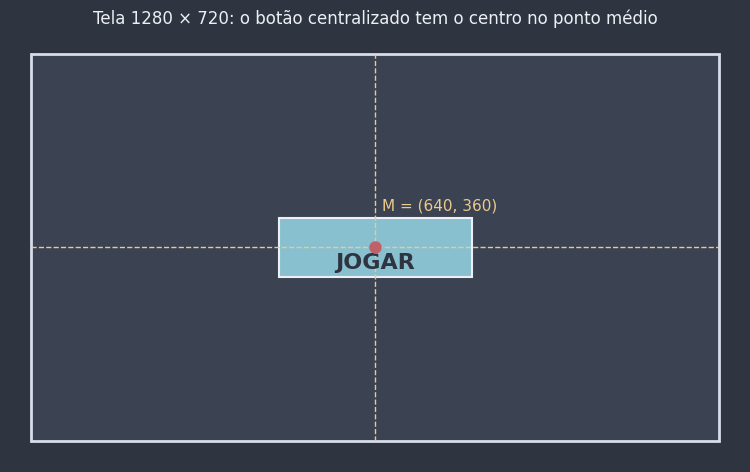

············SEGMENTO DE RETA············


In [14]:
largura_tela, altura_tela = 1280, 720
largura_botao, altura_botao = 360, 110

# Centro da tela = ponto médio das bordas, em cada direção
centro_x = (0 + largura_tela) / 2
centro_y = (0 + altura_tela) / 2
canto_botao = (centro_x - largura_botao / 2, centro_y - altura_botao / 2)
print(f"Centro da tela: ({centro_x:g}, {centro_y:g})")
print(f"O botão começa em x = {canto_botao[0]:g} e termina em x = {canto_botao[0] + largura_botao:g}")
print(f"Sobra à esquerda: {canto_botao[0]:g} px | sobra à direita: {largura_tela - canto_botao[0] - largura_botao:g} px")

fig, ax = plt.subplots(figsize=(8, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)
ax.add_patch(plt.Rectangle((0, 0), largura_tela, altura_tela, facecolor=NORD_PAINEL, edgecolor=NORD_TEXTO_SEC, lw=2))
ax.add_patch(plt.Rectangle(canto_botao, largura_botao, altura_botao, facecolor=COR_PONTO, edgecolor=NORD_TEXTO, lw=1.5))
ax.text(centro_x, centro_y - 28, "JOGAR", color=NORD_FUNDO, fontsize=16, fontweight="bold", ha="center", va="center")
ax.plot([0, largura_tela], [centro_y, centro_y], color=COR_AVISO, lw=1, linestyle="--")
ax.plot([centro_x, centro_x], [0, altura_tela], color=COR_AVISO, lw=1, linestyle="--")
ax.plot(centro_x, centro_y, "o", color=COR_ALERTA, markersize=8, zorder=5)
ax.text(centro_x + 12, centro_y + 70, f"M = ({centro_x:g}, {centro_y:g})", color=COR_AVISO, fontsize=11)
ax.set_xlim(-40, largura_tela + 40)
ax.set_ylim(-40, altura_tela + 40)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Tela 1280 × 720: o botão centralizado tem o centro no ponto médio", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

# O próprio Python usa essa ideia para centralizar texto: sobra o mesmo espaço dos dois lados
print("SEGMENTO DE RETA".center(40, "·"))

📎 **Conexão:** o ponto médio volta logo no notebook 📌 Perpendicularidade (mediatriz de um segmento), porque a **mediatriz** de $\overline{AB}$ é a reta perpendicular ao segmento que passa exatamente pelo seu ponto médio. E também em 📌 Quadriláteros: definição, elementos e trapézios (a base média de um trapézio liga os pontos médios de dois lados).

📖 **Leitura complementar:** [Ponto médio](https://pt.wikipedia.org/wiki/Ponto_m%C3%A9dio)

**Pergunta de checagem:** se um segmento mede 10 cm, a que distância de cada extremidade fica o ponto médio?

**Pergunta de checagem:** M é o ponto médio de $\overline{AB}$ e AM = 4,5 cm. Quanto mede AB? E se, na reta numerada, A está em 2 e M em 7, em que posição está B?

## 4. Segmentos consecutivos, colineares e adjacentes; operações com segmentos

Quando olhamos para **dois** segmentos ao mesmo tempo, algumas relações entre eles ganham nome:

📌 **Segmentos consecutivos:** têm **uma extremidade em comum**. Exemplo: $\overline{AB}$ e $\overline{BC}$ (a extremidade comum é B).

📌 **Segmentos colineares:** estão contidos numa **mesma reta**.

📌 **Segmentos adjacentes:** são **consecutivos e colineares** e têm **apenas** a extremidade comum como ponto em comum, ou seja, ficam um "em continuação" do outro, sem se sobrepor.

As três propriedades são independentes o suficiente para aparecerem em várias combinações. Veja quatro casos:

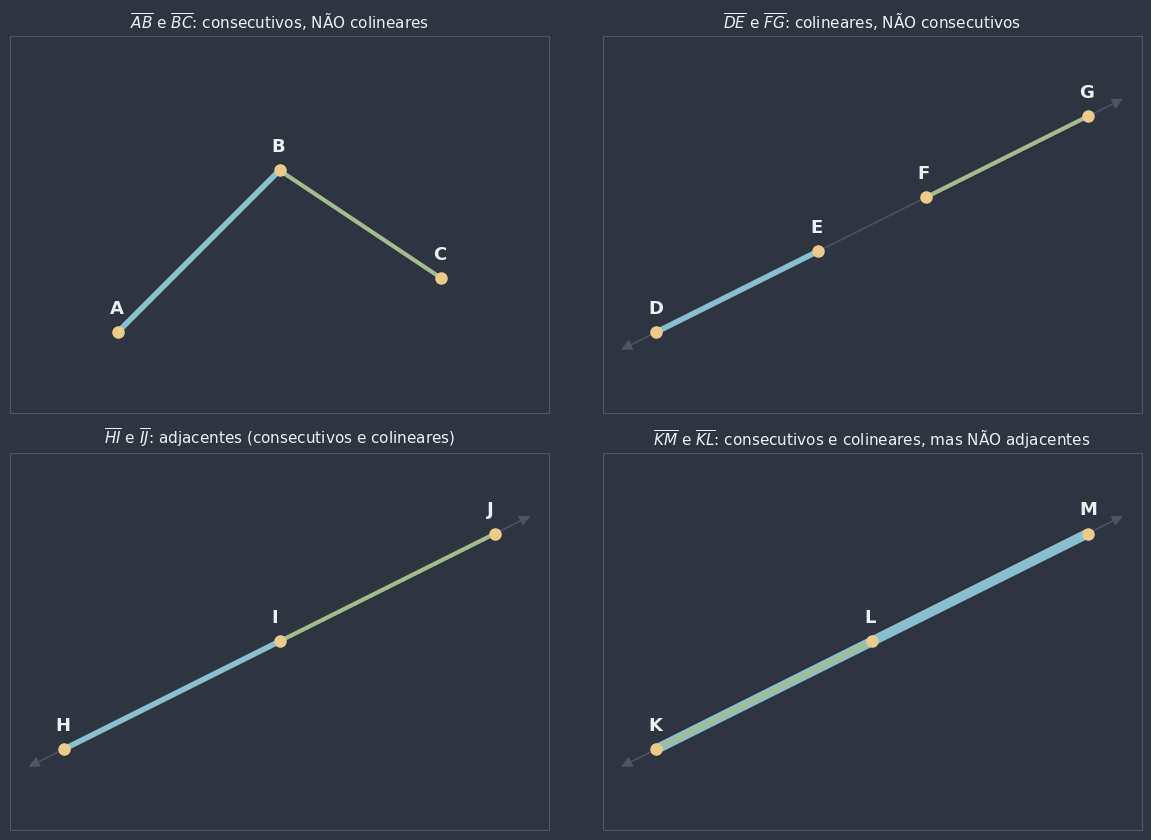

In [15]:
casos_de_pares = [
    ("consecutivos, NÃO colineares", {"A": (-3, -2), "B": (0, 1), "C": (3, -1)}, [("A", "B"), ("B", "C")]),
    ("colineares, NÃO consecutivos", {"D": (-4, -2), "E": (-1, -0.5), "F": (1, 0.5), "G": (4, 2)}, [("D", "E"), ("F", "G")]),
    ("adjacentes (consecutivos e colineares)", {"H": (-4, -2), "I": (0, 0), "J": (4, 2)}, [("H", "I"), ("I", "J")]),
    ("consecutivos e colineares, mas NÃO adjacentes", {"K": (-4, -2), "L": (0, 0), "M": (4, 2)}, [("K", "M"), ("K", "L")]),
]

fig, eixos = plt.subplots(2, 2, figsize=(12, 8.5))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (titulo, pontos, pares) in zip(eixos.flat, casos_de_pares):
    estilizar_eixo(ax)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    nomes = list(pontos)
    if "NÃO colineares" not in titulo:
        # reta suporte, bem apagada, para mostrar que estão na mesma reta
        desenhar_reta(ax, pontos[nomes[0]], pontos[nomes[-1]], cor=NORD_LINHA, lo=-5, hi=5, largura=1)
    (p1, p2), (q1, q2) = pares
    desenhar_segmento(ax, pontos[p1], pontos[p2], cor=COR_PONTO, largura=7 if "NÃO adjacentes" in titulo else 4)
    desenhar_segmento(ax, pontos[q1], pontos[q2], cor=COR_DESTAQUE, largura=3)
    for nome, p in pontos.items():
        desenhar_ponto(ax, p, nome, deslocamento=(-0.15, 0.35))
    legenda = f"$\\overline{{{p1}{p2}}}$ e $\\overline{{{q1}{q2}}}$: {titulo}"
    ax.set_title(legenda, color=NORD_TEXTO, fontsize=11)
plt.tight_layout()
plt.show()

No último caso, $\overline{KL}$ está **dentro** de $\overline{KM}$: os dois são consecutivos (extremidade comum K) e colineares, mas têm **muitos** pontos em comum (todo o $\overline{KL}$), não só o ponto K. Por isso não são adjacentes.

Dá para transformar as três definições em código. O teste de colinearidade é o mesmo de [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (multiplicação cruzada). Para decidir se dois segmentos consecutivos e colineares são adjacentes, olhamos para as **outras** duas extremidades: elas precisam ficar em **lados opostos** da extremidade comum.

In [16]:
def sao_colineares(*pontos: tuple[float, float]) -> bool:
    """Testa se todos os pontos estão numa mesma reta (os dois primeiros devem ser distintos)."""
    (xa, ya), (xb, yb) = pontos[0], pontos[1]
    return all(
        math.isclose((xb - xa) * (yc - ya) - (yb - ya) * (xc - xa), 0, abs_tol=1e-9)
        for xc, yc in pontos[2:]
    )


def classificar_par(seg1: tuple, seg2: tuple) -> dict[str, bool]:
    """Classifica dois segmentos (cada um dado por suas duas extremidades) como consecutivos, colineares e/ou adjacentes."""
    comuns = set(seg1) & set(seg2)
    consecutivos = len(comuns) == 1
    colineares = sao_colineares(*seg1, *seg2)
    adjacentes = False
    if consecutivos and colineares:
        comum = comuns.pop()
        outra_1 = next(p for p in seg1 if p != comum)
        outra_2 = next(p for p in seg2 if p != comum)
        # lados opostos da extremidade comum <=> os "vetores" até as outras pontas apontam em sentidos contrários
        adjacentes = np.dot(np.subtract(outra_1, comum), np.subtract(outra_2, comum)) < 0
    return {"consecutivos": consecutivos, "colineares": colineares, "adjacentes": bool(adjacentes)}


linhas = []
for titulo, pontos, ((p1, p2), (q1, q2)) in casos_de_pares:
    resultado = classificar_par((pontos[p1], pontos[p2]), (pontos[q1], pontos[q2]))
    linhas.append({"par": f"{p1}{p2} e {q1}{q2}", **{k: marca(v) for k, v in resultado.items()}})
display(pd.DataFrame(linhas).style.hide(axis="index"))

par,consecutivos,colineares,adjacentes
AB e BC,✅,❌,❌
DE e FG,❌,✅,❌
HI e IJ,✅,✅,✅
KM e KL,✅,✅,❌


**Operações com segmentos.** Quando $\overline{AB}$ e $\overline{BC}$ são **adjacentes** (ou seja, B está entre A e C na mesma reta), os dois juntos formam exatamente o segmento $\overline{AC}$. Por isso, as medidas se somam:

$$AC = AB + BC$$

E, isolando uma das partes, obtemos a **subtração**: $\quad BC = AC - AB \quad$ e $\quad AB = AC - BC$.

Vamos confirmar numericamente, na reta numerada e no plano:

In [17]:
# Na reta numerada: A em 1, B em 4, C em 9 (nessa ordem)
a, b, c = 1, 4, 9
print("Na reta numerada:")
print(f"  AB + BC = {abs(b - a)} + {abs(c - b)} = {abs(b - a) + abs(c - b)}   |   AC = {abs(c - a)}")
print(f"  Subtração: BC = AC - AB = {abs(c - a)} - {abs(b - a)} = {abs(c - a) - abs(b - a)}")

# No plano: A, B, C sobre a reta y = x/2, com B entre A e C
ponto_a, ponto_b, ponto_c = (0, 0), (2, 1), (8, 4)
ab, bc, ac = medida_segmento(ponto_a, ponto_b), medida_segmento(ponto_b, ponto_c), medida_segmento(ponto_a, ponto_c)
print("\nNo plano:")
print(f"  AB = {ab:.4f}, BC = {bc:.4f}, AB + BC = {ab + bc:.4f}   |   AC = {ac:.4f}")
print(f"  AC = AB + BC? {math.isclose(ab + bc, ac)}")

Na reta numerada:
  AB + BC = 3 + 5 = 8   |   AC = 8
  Subtração: BC = AC - AB = 8 - 3 = 5

No plano:
  AB = 2.2361, BC = 6.7082, AB + BC = 8.9443   |   AC = 8.9443
  AC = AB + BC? True


**Atenção:** a soma só funciona quando B está **entre** A e C. Se B estiver na mesma reta mas **fora** do segmento $\overline{AC}$, ou **fora da reta**, a soma $AB + BC$ passa de $AC$. A tabela mostra os três casos:

In [18]:
ponto_a, ponto_c = (0, 0), (8, 4)
posicoes_de_b = {
    "B entre A e C (na reta)": (2, 1),
    "B na reta, mas depois de C": (10, 5),
    "B fora da reta": (2, 4),
}
linhas = []
for situacao, b in posicoes_de_b.items():
    soma = medida_segmento(ponto_a, b) + medida_segmento(b, ponto_c)
    ac = medida_segmento(ponto_a, ponto_c)
    linhas.append({"situação": situacao, "B": b, "AB + BC": soma, "AC": ac, "AB + BC = AC?": marca(math.isclose(soma, ac))})
display(pd.DataFrame(linhas).style.format({"AB + BC": "{:.4f}", "AC": "{:.4f}"}).hide(axis="index"))

situação,B,AB + BC,AC,AB + BC = AC?
B entre A e C (na reta),"(2, 1)",8.9443,8.9443,✅
"B na reta, mas depois de C","(10, 5)",13.4164,8.9443,❌
B fora da reta,"(2, 4)",10.4721,8.9443,❌


🎯 **Aplicação prática — uma viagem com parada no posto:** uma estrada reta liga a cidade A à cidade C, a 420 km de distância. No meio do caminho há um posto de gasolina P. Se o posto está **na estrada**, os trechos $\overline{AP}$ e $\overline{PC}$ são adjacentes e a viagem total continua sendo $AP + PC = AC = 420$ km, não importa onde fique o posto. Mas se for preciso **desviar** da estrada para chegar ao posto, o caminho fica mais longo.

🕹️ **Widget interativo:** mova o posto ao longo da estrada (`km do posto`) e depois aumente o `desvio`, que tira o posto de cima da estrada. Observe quando $AP + PC$ é igual a $AC$ e quando passa dele.

In [19]:
distancia_ac = 420


def viagem_com_parada(km_do_posto: float, desvio: float) -> None:
    cidade_a, cidade_c = (0, 0), (distancia_ac, 0)
    posto = (km_do_posto, desvio)
    ap, pc = medida_segmento(cidade_a, posto), medida_segmento(posto, cidade_c)

    fig, ax = plt.subplots(figsize=(10, 3.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.set_xlim(-30, distancia_ac + 30)
    ax.set_ylim(-45, 130)
    ax.set_xlabel("km", color=NORD_TEXTO_SEC)
    ax.plot([0, distancia_ac], [0, 0], color=NORD_LINHA, lw=10, solid_capstyle="round", zorder=1)
    desenhar_segmento(ax, cidade_a, posto, cor=COR_PONTO, largura=3)
    desenhar_segmento(ax, posto, cidade_c, cor=COR_DESTAQUE, largura=3)
    desenhar_ponto(ax, cidade_a, "A", deslocamento=(-8, 12))
    desenhar_ponto(ax, cidade_c, "C", deslocamento=(-4, 12))
    desenhar_ponto(ax, posto, "P (posto)", cor=COR_ALERTA, deslocamento=(-10, 12))
    ax.text(5, -35, f"AP = {ap:.1f} km   +   PC = {pc:.1f} km   =   {ap + pc:.1f} km", color=NORD_TEXTO, fontsize=11)

    if math.isclose(desvio, 0):
        titulo, cor = f"Posto na estrada: AP + PC = AC = {distancia_ac} km (adjacentes)", COR_DESTAQUE
    else:
        titulo, cor = f"Desvio de {desvio:g} km: AP + PC = {ap + pc:.1f} km > AC = {distancia_ac} km", COR_AVISO
    ax.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    viagem_com_parada,
    km_do_posto=widgets.FloatSlider(value=150, min=0, max=distancia_ac, step=10, description="km do posto:"),
    desvio=widgets.FloatSlider(value=0, min=0, max=100, step=5, description="desvio (km):"),
);

interactive(children=(FloatSlider(value=150.0, description='km do posto:', max=420.0, step=10.0), FloatSlider(…

⚠️ **Erro comum:** achar que segmentos consecutivos são sempre colineares. Não são! $\overline{AB}$ e $\overline{BC}$ podem formar uma "quina", como os dois lados de um triângulo que saem do mesmo vértice. Só quando, além de consecutivos, estão na **mesma reta** e sem se sobrepor é que são chamados de **adjacentes**, e só aí vale $AC = AB + BC$.

💡 **Dica:** o widget da viagem antecipa um resultado importante: o caminho A → P → C **nunca é mais curto** que o caminho direto de A até C, e só é igual quando P está no segmento $\overline{AC}$. É a mesma ideia do gancho (o caminho em linha reta é o mais curto) e vai reaparecer em 📌 Triângulos (desigualdade triangular).

**Pergunta de checagem:** dois segmentos podem ser consecutivos e **não** serem colineares? Dê um exemplo com objetos do dia a dia.

**Pergunta de checagem:** A, B e C estão numa reta, nessa ordem, com AC = 12 cm e AB = 5 cm. Quanto mede BC? E se a ordem fosse A, C, B, com as mesmas medidas AC e AB, o que mudaria?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Reta $\overleftrightarrow{AB}$ | ilimitada nos **dois** sentidos |
| Semirreta $\overrightarrow{AB}$ | começa na **origem** A e segue ilimitada no sentido de B; um ponto divide a reta em duas semirretas **opostas** |
| Segmento $\overline{AB}$ ou $[AB]$ | reunião de A, B e dos pontos **entre** eles; limitado dos dois lados; **nulo** quando A = B |
| Na reta numerada ($a < b$) | $\overline{AB} = [a, b]$, $\ \overrightarrow{AB} = [a, +\infty[$, $\ \overline{AB} = \overrightarrow{AB} \cap \overrightarrow{BA}$ |
| Medida AB | número positivo (zero só no segmento nulo); reta numerada: $AB = \lvert b - a \rvert$ |
| Distância no plano | $AB = \sqrt{(x_B - x_A)^2 + (y_B - y_A)^2}$ |
| Congruência | $\overline{AB} \equiv \overline{CD} \iff AB = CD$; reflexiva, simétrica e transitiva |
| Ponto médio M | $M \in \overline{AB}$ e $\overline{AM} \equiv \overline{MB}$, logo $AM = MB = AB/2$; é único |
| Coordenadas do ponto médio | $M = \left(\frac{x_A + x_B}{2}, \frac{y_A + y_B}{2}\right)$; na reta: $m = \frac{a + b}{2}$ |
| Consecutivos | têm **uma extremidade em comum** |
| Colineares | estão na **mesma reta** |
| Adjacentes | consecutivos **e** colineares, com só a extremidade comum em comum |
| Soma e subtração | se B está entre A e C: $AC = AB + BC$ e $BC = AC - AB$ |

**A ideia central:** o segmento é o "pedaço de reta que dá para medir". Com ele a geometria ganha números: medidas para comparar (congruência), dividir ao meio (ponto médio) e somar (segmentos adjacentes). Toda medida de lado, perímetro e distância que vem pela frente é medida de segmento.

## Exercícios

**Básico**
1. Calcular medidas de segmentos a partir das posições dos pontos numa reta numerada.
2. Classificar pares de segmentos desenhados como consecutivos, colineares e/ou adjacentes.

**Intermediário**
3. Escrever uma função que calcula o ponto médio de um segmento e verificar que as duas metades são congruentes.
4. Usar a soma de segmentos adjacentes numa estrada e testar, com código, quando $AC = AB + BC$.

**Desafio**
5. Calcular a razão $AP/PB$ para um ponto P qualquer do segmento $\overline{AB}$.
6. Fazer o caminho inverso: encontrar o ponto P que divide $\overline{AB}$ numa razão dada.

Gabarito completo com resolução comentada em [`0402b_segmento_de_reta_gabarito.ipynb`](0402b_segmento_de_reta_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: numa reta numerada estão marcados os pontos
# A em -3, B em 2, C em 5.5 e D em -7.
# Calcule a medida de cada segmento abaixo (lembre: medida nunca é negativa).
posicao = {"A": -3, "B": 2, "C": 5.5, "D": -7}

medida_ab = ...
medida_bc = ...
medida_ad = ...
medida_cd = ...

print(medida_ab, medida_bc, medida_ad, medida_cd)

In [ ]:
# Verificação
respostas_ex1 = {"AB": (medida_ab, 5), "BC": (medida_bc, 3.5), "AD": (medida_ad, 4), "CD": (medida_cd, 12.5)}
for nome, (resposta, certa) in respostas_ex1.items():
    assert resposta is not ... and math.isclose(resposta, certa), (
        f"Tente de novo, revise: a medida de {nome} é o módulo da diferença entre as "
        "posições, |b - a|, e nunca dá negativa (seção 2 - Medida, comparação e "
        "congruência de segmentos)."
    )
print("Certo!")

Execute a célula abaixo para ver os desenhos do Exercício Básico 2.

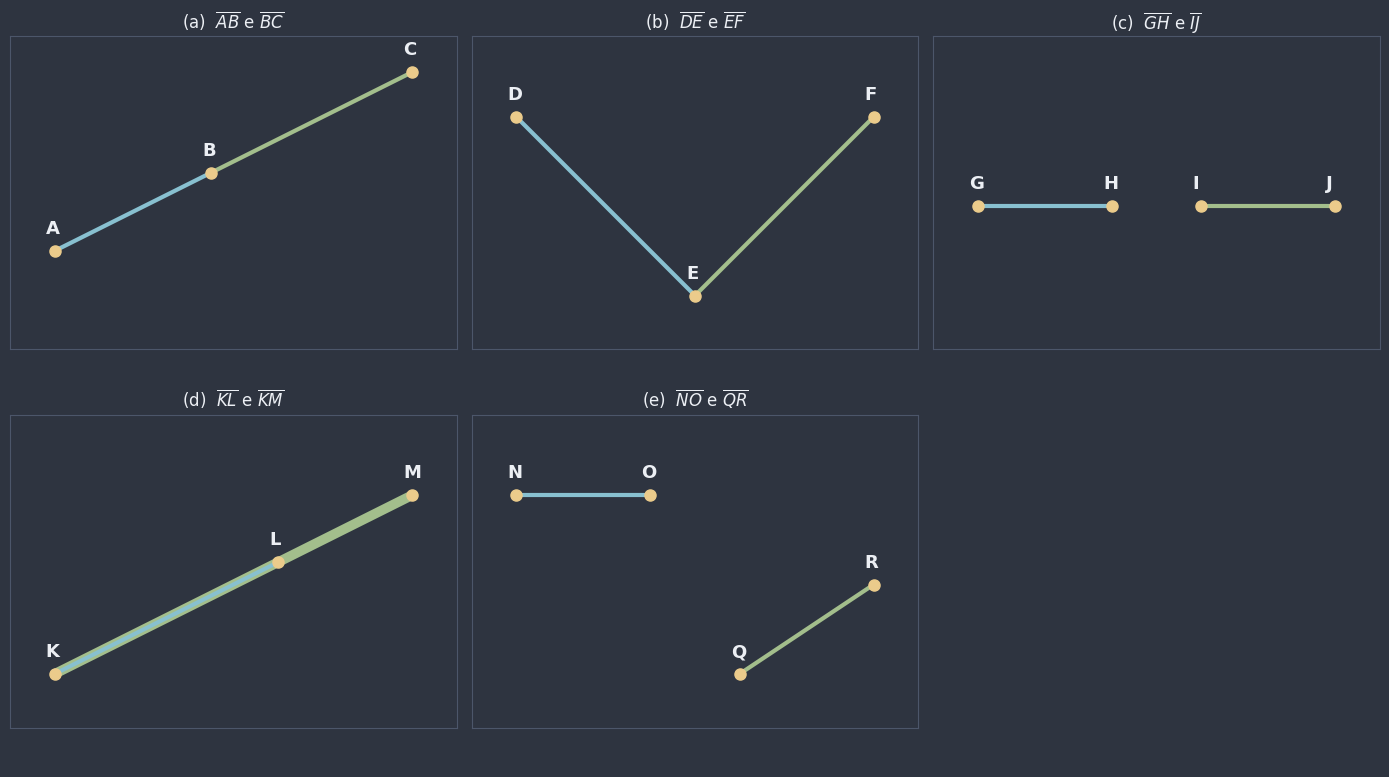

In [20]:
# Figura do Exercício Básico 2 (apenas desenha os pares; não precisa alterar)
pares_ex2 = {
    "a": ({"A": (-4, -1), "B": (-0.5, 0.75), "C": (4, 3)}, [("A", "B"), ("B", "C")]),
    "b": ({"D": (-4, 2), "E": (0, -2), "F": (4, 2)}, [("D", "E"), ("E", "F")]),
    "c": ({"G": (-4, 0), "H": (-1, 0), "I": (1, 0), "J": (4, 0)}, [("G", "H"), ("I", "J")]),
    "d": ({"K": (-4, -2), "L": (1, 0.5), "M": (4, 2)}, [("K", "L"), ("K", "M")]),
    "e": ({"N": (-4, 2), "O": (-1, 2), "Q": (1, -2), "R": (4, 0)}, [("N", "O"), ("Q", "R")]),
}

fig, eixos = plt.subplots(2, 3, figsize=(14, 8))
eixos[1, 2].axis("off")
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (letra, (pontos, ((p1, p2), (q1, q2)))) in zip(eixos.flat, pares_ex2.items()):
    estilizar_eixo(ax)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3.2, 3.8)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    grosso = letra == "d"
    desenhar_segmento(ax, pontos[q1], pontos[q2], cor=COR_DESTAQUE, largura=7 if grosso else 3)
    desenhar_segmento(ax, pontos[p1], pontos[p2], cor=COR_PONTO, largura=3)
    for nome, p in pontos.items():
        desenhar_ponto(ax, p, nome, deslocamento=(-0.2, 0.4))
    ax.set_title(f"({letra})  $\\overline{{{p1}{p2}}}$ e $\\overline{{{q1}{q2}}}$", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Básico 2: para cada par de segmentos (a) a (e) da figura acima,
# responda com uma tupla (consecutivos, colineares, adjacentes), usando True
# ou False em cada posição.
# Dica: nos pares (a) e (d), confira as coordenadas em `pares_ex2` para ter
# certeza de que os pontos estão alinhados.
classificacao_ex2 = {
    "a": ...,
    "b": ...,
    "c": ...,
    "d": ...,
    "e": ...,
}

print(classificacao_ex2)

In [ ]:
# Verificação
gabarito_ex2 = {
    "a": (True, True, True),
    "b": (True, False, False),
    "c": (False, True, False),
    "d": (True, True, False),
    "e": (False, False, False),
}
dicas_ex2 = {
    "a": "B está entre A e C, na mesma reta",
    "b": "D, E e F formam uma quina: não há uma reta que passe pelos três",
    "c": "os dois estão no eixo horizontal, mas não dividem nenhuma extremidade",
    "d": "KL e KM compartilham K e estão na mesma reta, mas KL fica DENTRO de KM",
    "e": "os segmentos não têm extremidade comum nem estão na mesma reta",
}
for letra, certa in gabarito_ex2.items():
    assert tuple(classificacao_ex2[letra]) == certa, (
        f"Tente de novo, revise: no par ({letra}), {dicas_ex2[letra]} "
        "(seção 4 - Segmentos consecutivos, colineares e adjacentes)."
    )
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: complete a função `ponto_medio_ex3`, que recebe
# as extremidades p1 e p2 (tuplas (x, y)) e devolve o ponto médio como tupla.
# Depois, use-a para calcular o ponto médio `m_ex3` do segmento de
# extremidades A = (-4, 7) e B = (10, -3).


def ponto_medio_ex3(p1: tuple[float, float], p2: tuple[float, float]) -> tuple[float, float]:
    ...


a_ex3, b_ex3 = (-4, 7), (10, -3)
m_ex3 = ...

print(m_ex3)

In [ ]:
# Verificação
assert m_ex3 is not ... and tuple(m_ex3) == (3, 2), (
    "Tente de novo, revise: cada coordenada de M é a média das coordenadas de A e B, "
    "((x_A + x_B)/2, (y_A + y_B)/2) (seção 3 - Ponto médio de um segmento)."
)
casos_ex3 = [((0, 0), (8, 0)), ((2, 7), (2, -1)), ((-4, 5), (1, -2)), ((1.5, 2.5), (6.5, 0.5)), ((3, 3), (3, 3))]
for p1, p2 in casos_ex3:
    m = ponto_medio_ex3(p1, p2)
    assert m is not None and math.isclose(m[0], (p1[0] + p2[0]) / 2) and math.isclose(m[1], (p1[1] + p2[1]) / 2), (
        f"Tente de novo, revise: para A = {p1} e B = {p2}, a função devolveu {m}; "
        "faça a média de x e a média de y separadamente (seção 3 - Ponto médio de um segmento)."
    )
    # as duas metades precisam ser congruentes
    assert math.isclose(math.dist(p1, m), math.dist(m, p2)), (
        "Tente de novo, revise: AM e MB deveriam ter a mesma medida "
        "(seção 3 - Ponto médio de um segmento)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4:
# (a) Uma estrada reta passa pelas cidades A, B e C, nessa ordem.
#     De A até C são 350 km, e de A até B são 128 km. Quantos km há de B até C?
#     Guarde o valor em `medida_bc_ex4`.
# (b) Complete a função `b_entre_a_e_c`, que recebe três pontos do plano
#     (tuplas (x, y)) e devolve True se AB + BC = AC (ou seja, se B está no
#     segmento AC) e False caso contrário.
#     Dica: compare números decimais com math.isclose, nunca com ==.
medida_bc_ex4 = ...


def b_entre_a_e_c(a: tuple[float, float], b: tuple[float, float], c: tuple[float, float]) -> bool:
    ...


print(medida_bc_ex4, b_entre_a_e_c((0, 0), (2, 1), (8, 4)))

In [ ]:
# Verificação
assert medida_bc_ex4 == 222, (
    "Tente de novo, revise: com B entre A e C, AC = AB + BC, então BC = AC - AB "
    "(seção 4 - Operações com segmentos)."
)
assert b_entre_a_e_c((0, 0), (2, 1), (8, 4)) is True, (
    "Tente de novo, revise: (2, 1) está na reta y = x/2, entre (0, 0) e (8, 4); a soma "
    "AB + BC deve dar AC (seção 4 - Operações com segmentos)."
)
assert b_entre_a_e_c((1, 1), (1, 4), (1, 9)) is True, (
    "Tente de novo, revise: B = (1, 4) está entre A e C na reta vertical x = 1 "
    "(seção 4 - Operações com segmentos)."
)
assert b_entre_a_e_c((0, 0), (10, 5), (8, 4)) is False, (
    "Tente de novo, revise: B = (10, 5) está na mesma reta, mas DEPOIS de C; aí AB + BC "
    "passa de AC (seção 4 - Operações com segmentos)."
)
assert b_entre_a_e_c((0, 0), (2, 4), (8, 4)) is False, (
    "Tente de novo, revise: B = (2, 4) está fora da reta AC, e o caminho A -> B -> C fica "
    "mais longo que AC (seção 4 - Operações com segmentos)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: P é um ponto do segmento AB, diferente de B.
# Complete a função `razao_ap_pb`, que devolve a razão AP / PB.
# Depois responda: qual é essa razão quando P é o ponto médio de AB?
# Guarde a resposta em `razao_no_ponto_medio`.
# (Razões entre segmentos são a base do Teorema de Tales, mais à frente no módulo.)


def razao_ap_pb(a: tuple[float, float], b: tuple[float, float], p: tuple[float, float]) -> float:
    ...


razao_no_ponto_medio = ...

print(razao_ap_pb((0, 0), (10, 0), (4, 0)), razao_no_ponto_medio)

In [ ]:
# Verificação (compara sua função com uma função de referência)
def _razao_referencia(a, b, p) -> float:
    return math.dist(a, p) / math.dist(p, b)


segmentos_ex5 = [((0, 0), (10, 0)), ((-3, -1), (5, 3)), ((2, 7), (2, -1))]
for a, b in segmentos_ex5:
    for t in [0, 0.1, 0.25, 0.5, 2 / 3, 0.8, 0.95]:
        p = (a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1]))
        assert math.isclose(razao_ap_pb(a, b, p), _razao_referencia(a, b, p), abs_tol=1e-9), (
            f"Tente de novo, revise: para A = {a}, B = {b} e P = {p}, AP/PB deveria dar "
            f"{_razao_referencia(a, b, p):.4f}; calcule AP e PB com a fórmula da distância "
            "e divida (seção 2 - Medida, comparação e congruência de segmentos)."
        )
assert razao_no_ponto_medio == 1, (
    "Tente de novo, revise: no ponto médio, AM = MB, então a razão é um número bem "
    "simples (seção 3 - Ponto médio de um segmento)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: agora o caminho inverso. Dados A, B e um número k > 0,
# complete a função `ponto_que_divide`, que devolve o ponto P do segmento AB
# tal que AP / PB = k.
# Dica: se AP / PB = k, então AP é k "partes" e PB é 1 "parte"; o segmento
# todo tem k + 1 partes. Que fração do caminho de A até B o ponto P andou?
# Use essa fração em cada coordenada, como no ponto médio (que é o caso k = 1).


def ponto_que_divide(a: tuple[float, float], b: tuple[float, float], k: float) -> tuple[float, float]:
    ...


print(ponto_que_divide((0, 0), (9, 0), 2))

In [ ]:
# Verificação
segmentos_ex6 = [((0, 0), (9, 0)), ((-3, -1), (5, 3)), ((2, 7), (2, -1)), ((1, 1), (-4, 6))]
for a, b in segmentos_ex6:
    for k in [0.5, 1, 2, 3, 7.5]:
        p = ponto_que_divide(a, b, k)
        assert p is not None and math.isclose(math.dist(a, p) + math.dist(p, b), math.dist(a, b)), (
            f"Tente de novo, revise: para A = {a}, B = {b} e k = {k}, o ponto {p} não está "
            "no segmento AB (seção 4 - Operações com segmentos)."
        )
        assert math.isclose(math.dist(a, p) / math.dist(p, b), k), (
            f"Tente de novo, revise: para A = {a}, B = {b} e k = {k}, a razão AP/PB deu "
            f"{math.dist(a, p) / math.dist(p, b):.4f}; P anda a fração k/(k + 1) do caminho "
            "de A até B (seção 3 - Ponto médio de um segmento)."
        )
assert ponto_que_divide((-3, -1), (5, 3), 1) == (1, 1), (
    "Tente de novo, revise: com k = 1 o ponto deve ser o ponto médio "
    "(seção 3 - Ponto médio de um segmento)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (ponto, reta, notação, postulado de determinação da reta, teste de colinearidade)
- [`0103a_conjuntos_numericos.ipynb`](../01_conjuntos_e_funcoes/0103a_conjuntos_numericos.ipynb) (intervalos da reta real, base da notação $[AB]$)
- [`0110a_funcao_modular.ipynb`](../01_conjuntos_e_funcoes/0110a_funcao_modular.ipynb) (módulo, usado na medida $AB = |b - a|$)
- [`0104a_relacoes.ipynb`](../01_conjuntos_e_funcoes/0104a_relacoes.ipynb) (propriedades reflexiva, simétrica e transitiva da congruência)

**Isso será usado em:**
- 📌 Ângulos (ângulo como reunião de duas semirretas de mesma origem, os lados do ângulo)
- 📌 Perpendicularidade (mediatriz: a perpendicular a um segmento pelo seu ponto médio)
- 📌 Quadriláteros: definição, elementos e trapézios (base média, que liga pontos médios de lados)
- 📌 Teorema de Tales (razão entre segmentos, retomando os Desafios 5 e 6)
- 📌 Triângulos (lados como segmentos consecutivos e a desigualdade triangular, antecipada no widget da viagem)
- [`0501a_arcos_e_angulos.ipynb`](../05_trigonometria/0501a_arcos_e_angulos.ipynb) (ângulo como reunião de duas semirretas de mesma origem)
- 📌 Geometria Analítica (distância entre dois pontos e ponto médio com coordenadas, formalizados)